# Phân tích mối quan hệ giữa ngành hàng và hiệu quả bán (Outer)

## Thành viên: Mạnh

### Mục tiêu phân tích:
1. **Câu hỏi 1**: Rating của người dùng (`rating_avg`) ảnh hưởng đến hiệu quả bán (`sold_count`) khác nhau thế nào giữa các ngành hàng? Ngành nào nhạy với rating hơn?
2. **Câu hỏi 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?

In [5]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Tạo thư mục output nếu chưa có
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Nạp bộ dữ liệu dùng chung

In [6]:
# Nạp 4 bảng dữ liệu theo chuẩn chung của nhóm
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Kích thước dữ liệu:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Kích thước dữ liệu:
Stores: (1446, 5)
Categories: (496, 4)
Products: (55883, 14)
Reviews: (158126, 9)


## 2. Câu hỏi nghiên cứu: Rating ảnh hưởng đến hiệu quả bán theo ngành hàng thế nào?

In [7]:
# Chuẩn bị dữ liệu cho phân tích rating
df_rating_01 = df_product.merge(df_category, on='category_id', how='left')

# Tương thích nhiều schema đầu vào
source_col = 'source_category_x' if 'source_category_x' in df_rating_01.columns else 'source_category'
if source_col not in df_rating_01.columns:
    raise KeyError("Không tìm thấy cột source_category trong dữ liệu sản phẩm")

# Chỉ giữ các bản ghi hợp lệ
df_rating_01 = df_rating_01[
    (df_rating_01['rating_avg'] > 0) & 
    (df_rating_01['sold_count'] > 0) &
    (df_rating_01['review_count'] > 0) &
    (df_rating_01[source_col].notna())
].copy()

# Ánh xạ tên ngành hàng sang nhãn dễ đọc
category_mapping = {
    'diengiadung': 'Đồ gia dụng',
    'dientu_dienlanh': 'Điện tử - Điện lạnh',
    'dienthoai_maytinhbang': 'Điện thoại - Máy tính bảng',
    'laptop_mayvitinh_linhkien': 'Laptop - Máy tính - Linh kiện',
    'thietbiso_phukienso': 'Thiết bị số - Phụ kiện số'
}

df_rating_01['category_name'] = df_rating_01[source_col].map(category_mapping)
df_rating_01 = df_rating_01[df_rating_01['category_name'].notna()]

# Chia nhóm rating
df_rating_01['rating_group'] = pd.cut(
    df_rating_01['rating_avg'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=['Thấp (<3.5)', 'Trung bình (3.5-4.0)', 'Tốt (4.0-4.5)', 'Xuất sắc (4.5-5.0)']
)

print(f"Tổng số sản phẩm có rating hợp lệ: {len(df_rating_01)}")
print(f"\nPhân bố theo ngành hàng:")
print(df_rating_01['category_name'].value_counts())

Tổng số sản phẩm có rating hợp lệ: 10283

Phân bố theo ngành hàng:
category_name
Thiết bị số - Phụ kiện số        6234
Đồ gia dụng                      2578
Laptop - Máy tính - Linh kiện    1148
Điện tử - Điện lạnh               275
Điện thoại - Máy tính bảng         48
Name: count, dtype: int64


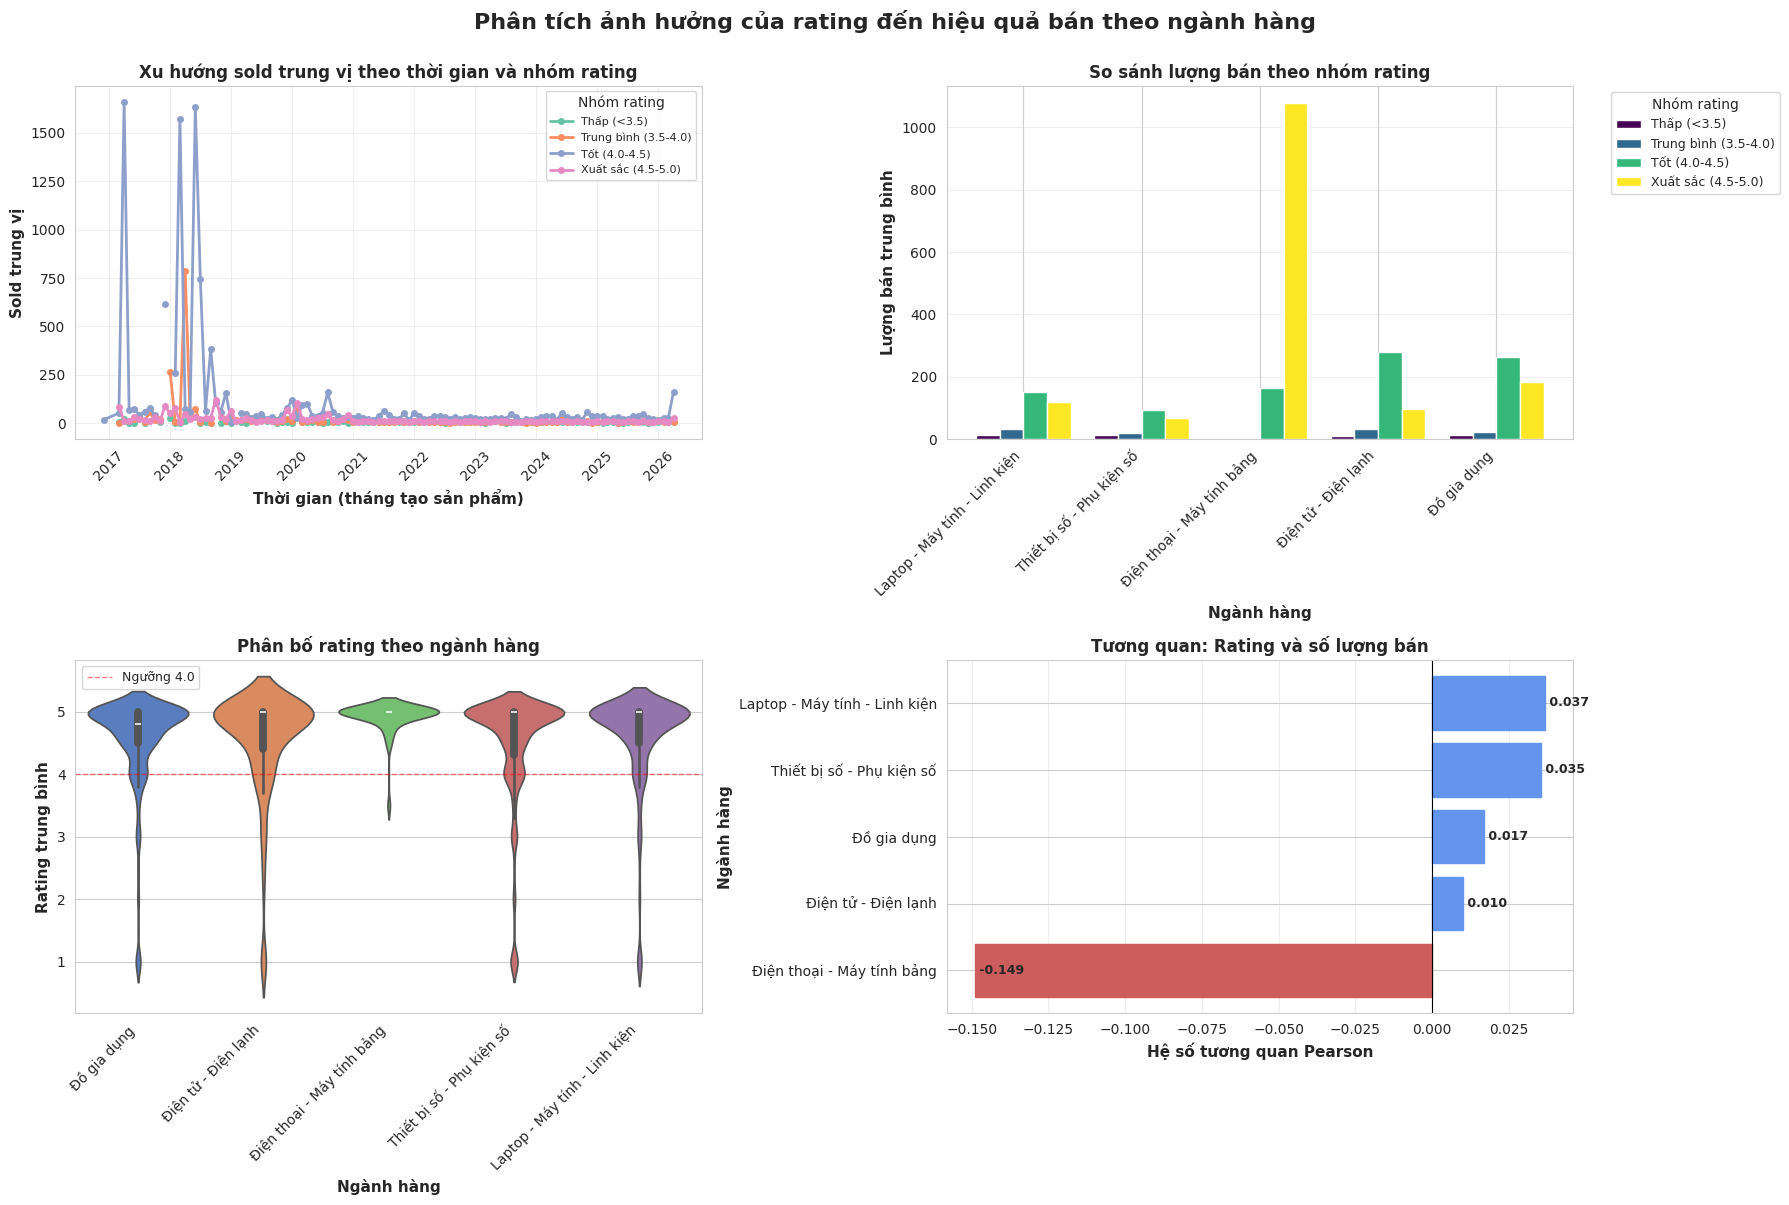


THỐNG KÊ BỔ SUNG - PHÂN TÍCH RATING
                               Rating TB  Rating trung vị  Review TB  \
category_name                                                          
Điện thoại - Máy tính bảng          4.92              5.0      61.77   
Laptop - Máy tính - Linh kiện       4.61              5.0      14.23   
Đồ gia dụng                         4.55              4.8      32.55   
Điện tử - Điện lạnh                 4.53              5.0       6.39   
Thiết bị số - Phụ kiện số           4.47              5.0      11.20   

                               Tổng review  Sold TB  Tổng sold  
category_name                                                   
Điện thoại - Máy tính bảng            2965  1018.73      48899  
Laptop - Máy tính - Linh kiện        16332   105.98     121661  
Đồ gia dụng                          83903   166.74     429848  
Điện tử - Điện lạnh                   1757   100.71      27696  
Thiết bị số - Phụ kiện số            69829    59.78     372662  

Ph

In [8]:
# Trực quan hóa cho câu hỏi rating
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân tích ảnh hưởng của rating đến hiệu quả bán theo ngành hàng', 
             fontsize=16, fontweight='bold', y=1.00)

categories = df_rating_01['category_name'].unique()

# Biểu đồ 1: Time series - Xu hướng sold theo thời gian và nhóm rating
ax1 = axes[0, 0]
df_time = df_rating_01.copy()
df_time['created_at_dt'] = pd.to_datetime(df_time['created_at'], errors='coerce')
df_time = df_time.dropna(subset=['created_at_dt'])
df_time['created_month'] = df_time['created_at_dt'].dt.to_period('M').dt.to_timestamp()

monthly_rating = (
    df_time.groupby(['created_month', 'rating_group'], observed=False)['sold_count']
    .median()
    .reset_index()
    .sort_values('created_month')
)

rating_order = df_rating_01['rating_group'].cat.categories
time_colors = dict(zip(rating_order, sns.color_palette('Set2', len(rating_order))))

for group in rating_order:
    group_data = monthly_rating[monthly_rating['rating_group'] == group]
    if not group_data.empty:
        ax1.plot(
            group_data['created_month'],
            group_data['sold_count'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=str(group),
            color=time_colors[group]
        )

ax1.set_xlabel('Thời gian (tháng tạo sản phẩm)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Sold trung vị', fontsize=11, fontweight='bold')
ax1.set_title('Xu hướng sold trung vị theo thời gian và nhóm rating', fontsize=12, fontweight='bold')
ax1.legend(title='Nhóm rating', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Biểu đồ 2: Bar chart nhóm - Lượng bán trung bình theo nhóm rating và ngành hàng
ax2 = axes[0, 1]
grouped_data = df_rating_01.groupby(['category_name', 'rating_group'], observed=False)['sold_count'].mean().unstack(fill_value=0)
grouped_data.plot(kind='bar', ax=ax2, width=0.8, colormap='viridis')
ax2.set_xlabel('Ngành hàng', fontsize=11, fontweight='bold')
ax2.set_ylabel('Lượng bán trung bình', fontsize=11, fontweight='bold')
ax2.set_title('So sánh lượng bán theo nhóm rating', fontsize=12, fontweight='bold')
ax2.legend(title='Nhóm rating', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Biểu đồ 3: Violin plot - Phân bố rating theo ngành hàng
ax3 = axes[1, 0]
sns.violinplot(data=df_rating_01, x='category_name', y='rating_avg', ax=ax3, palette='muted')
ax3.set_xlabel('Ngành hàng', fontsize=11, fontweight='bold')
ax3.set_ylabel('Rating trung bình', fontsize=11, fontweight='bold')
ax3.set_title('Phân bố rating theo ngành hàng', fontsize=12, fontweight='bold')
ax3.axhline(y=4.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Ngưỡng 4.0')
ax3.legend(fontsize=9)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

# Biểu đồ 4: Bar chart - Tương quan rating và sold_count theo ngành hàng
ax4 = axes[1, 1]
rating_correlations = []
for cat in categories:
    cat_data = df_rating_01[df_rating_01['category_name'] == cat]
    if len(cat_data) > 10:
        corr = cat_data[['rating_avg', 'sold_count']].corr().iloc[0, 1]
        rating_correlations.append({'category': cat, 'correlation': corr})

rating_corr_df = pd.DataFrame(rating_correlations).sort_values('correlation')
bars = ax4.barh(rating_corr_df['category'], rating_corr_df['correlation'])

# Tô màu theo dấu của hệ số tương quan
for bar, val in zip(bars, rating_corr_df['correlation']):
    if val < 0:
        bar.set_color('indianred')
    else:
        bar.set_color('cornflowerblue')

ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Hệ số tương quan Pearson', fontsize=11, fontweight='bold')
ax4.set_ylabel('Ngành hàng', fontsize=11, fontweight='bold')
ax4.set_title('Tương quan: Rating và số lượng bán', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Ghi chú giá trị lên cột
for i, (_, row) in enumerate(rating_corr_df.iterrows()):
    ax4.text(row['correlation'], i, f" {row['correlation']:.3f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('../output/question_2_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# In thống kê bổ sung
print("\n" + "="*80)
print("THỐNG KÊ BỔ SUNG - PHÂN TÍCH RATING")
print("="*80)
rating_stats = df_rating_01.groupby('category_name').agg({
    'rating_avg': ['mean', 'median'],
    'review_count': ['mean', 'sum'],
    'sold_count': ['mean', 'sum']
}).round(2)
rating_stats.columns = ['Rating TB', 'Rating trung vị', 'Review TB', 'Tổng review', 'Sold TB', 'Tổng sold']
print(rating_stats.sort_values('Rating TB', ascending=False))

# Thống kê theo nhóm rating
print("\n" + "="*80)
print("Phân bố lượng bán theo từng nhóm rating:")
print("="*80)
rating_group_stats = df_rating_01.groupby('rating_group', observed=False)['sold_count'].agg(['mean', 'median', 'count']).round(0)
rating_group_stats.columns = ['Trung bình', 'Trung vị', 'Số sản phẩm']
print(rating_group_stats)

# Kiểm tra định lượng hiệu ứng ngưỡng 4.0
print("\n" + "="*80)
print("KIỂM TRA HIỆU ỨNG NGƯỠNG 4.0")
print("="*80)
rating_mean_detail = (
    df_rating_01.groupby('rating_group', observed=False)['sold_count']
    .mean()
    .reindex(rating_order)
)
for group, value in rating_mean_detail.items():
    if pd.notna(value):
        print(f"{group}: {value:.2f}")

required_groups = {'Trung bình (3.5-4.0)', 'Tốt (4.0-4.5)', 'Xuất sắc (4.5-5.0)'}
if required_groups.issubset(set(rating_mean_detail.dropna().index)):
    jump_to_good = rating_mean_detail['Tốt (4.0-4.5)'] - rating_mean_detail['Trung bình (3.5-4.0)']
    jump_to_excellent = rating_mean_detail['Xuất sắc (4.5-5.0)'] - rating_mean_detail['Tốt (4.0-4.5)']
    print(f"\nMức tăng từ 3.5-4.0 lên 4.0-4.5: {jump_to_good:.2f}")
    print(f"Mức tăng từ 4.0-4.5 lên 4.5-5.0: {jump_to_excellent:.2f}")
    if jump_to_excellent <= 0:
        print("=> Doanh số không tăng tuyến tính sau mốc 4.0; lên nhóm xuất sắc thì sold trung bình không tăng thêm.")
    else:
        print("=> Doanh số vẫn tăng sau mốc 4.0 nhưng biên độ nhỏ hơn rõ rệt, nên xu hướng tuyến tính yếu.")

### Phân tích và kết luận

#### Các điểm nổi bật:

1. **Hiệu ứng ngưỡng 4.0 được xác nhận bằng kiểm tra định lượng**. Cụ thể, sold trung bình tăng từ **21.91** (nhóm 3.5-4.0) lên **154.00** (nhóm 4.0-4.5), tức tăng **132.09**, nhưng từ 4.0-4.5 lên 4.5-5.0 lại giảm **-42.80** xuống **111.20**, nên quan hệ không còn tuyến tính tuyệt đối sau mốc 4.0.
2. **Biểu đồ thời gian (dựa trên created_at) cho thấy hiệu ứng rating thay đổi theo từng giai đoạn thị trường**. Ở nhiều thời điểm, nhóm **Tốt (4.0-4.5)** bám sát hoặc vượt nhóm **Xuất sắc (4.5-5.0)**, nên doanh số không tăng đều chỉ vì rating cao hơn một chút mà còn phụ thuộc vào bối cảnh thị trường, chiến dịch và vòng đời sản phẩm.
3. **Nhóm Điện thoại - Máy tính bảng vẫn là ngoại lệ đáng chú ý khi có tương quan âm**. Dù hệ số tương quan ngành này là **-0.149**, cột so sánh theo nhóm rating cho thấy vẫn có cụm sản phẩm bán rất mạnh, gợi ý vai trò lớn của thương hiệu và model chủ lực.
4. **Các ngành công nghệ còn lại giữ tương quan dương nhưng biên độ nhẹ**. Laptop - Máy tính - Linh kiện (**0.037**) và Thiết bị số - Phụ kiện số (**0.035**) cho tín hiệu dương, tuy nhiên độ lớn nhỏ cho thấy rating chỉ là một phần trong hệ yếu tố quyết định doanh số.
5. **Phân bố rating dồn nhiều ở vùng cao làm giảm sức phân tách của chỉ số sao**. Khi phần lớn sản phẩm tập trung ở dải **4.5-5.0**, chỉ dùng rating sẽ khó phân biệt rõ lợi thế cạnh tranh giữa các sản phẩm trong cùng ngành.

#### Kết luận:

- **Mốc 4.0 sao là ngưỡng chất lượng quan trọng**, vì sau ngưỡng này doanh số có bước nhảy lớn ở dữ liệu hiện tại. Tuy nhiên, việc tăng từ mức tốt lên mức xuất sắc không bảo đảm sold tiếp tục tăng theo đường thẳng, người bán cần phải xem xét thêm các yếu tố khác để đảm bảo hiệu quả bán.
- **Tác động của rating có tính điều kiện theo ngành và theo thời điểm**, không phải quan hệ tuyến tính cố định. Vì vậy, nên đọc rating cùng bối cảnh danh mục, chu kỳ sản phẩm và tín hiệu thị trường.
- **Điện thoại - Máy tính bảng cần cách diễn giải riêng** do tương quan âm nhưng vẫn có cụm doanh số cao. Với nhóm này, phân tích thực tế nên ghép thêm các dữ liệu liên quan để hiểu rõ hơn.
- **Rating nên được xem là điều kiện cần hơn là điều kiện đủ** trong bài toán tăng trưởng. Để ra quyết định tối ưu, cần kết hợp thêm giá, review, độ phủ cửa hàng và nhịp thời gian tung sản phẩm.

## 3. Câu hỏi 2: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?

### Ghi chú phương pháp

- Revenue được ước lượng tương đối theo công thức `price * sold_count` (chấp nhận sai số do discount hoặc biến động giá thực tế).
- Ở pha modeling chính, chỉ dùng các feature có thể biết tại hoặc trước thời điểm mua để giảm rủi ro data leakage.
- Các feature từ review được tách ra để nhìn như tín hiệu hậu mua (post-purchase signal), không xem là yếu tố nhân quả.
- Sử dụng XGBoost để bắt quan hệ non-linear và tương tác giữa các biến.
- Feature importance chỉ phản ánh mức đóng góp cho bài toán dự đoán, không phải kết luận causal.

In [ ]:
# Chuẩn bị các biến nền để giữ nguyên logic code của Question 2
df_q1_category = df_category.copy()
df_q1_product = df_product.copy()

df_q1_product["revenue"] = df_q1_product["sold_count"] * df_q1_product["price"]

parent_map = dict(zip(df_q1_category["category_id"], df_q1_category["parent_category"]))
name_to_id = dict(zip(df_q1_category["category_name"], df_q1_category["category_id"]))

cat_to_root = {}
for cat_id in df_q1_category["category_id"]:
    current = cat_id
    while pd.notna(parent_map[current]):
        parent_name = parent_map[current]
        current = name_to_id[parent_name]
    cat_to_root[cat_id] = current

df_q1_product["root_category_id"] = df_q1_product["category_id"].map(cat_to_root)
cat_name_map = df_q1_category.set_index("category_id")["category_name"]
df_q1_product["category_name"] = df_q1_product["category_id"].map(cat_name_map)
df_q1_product["root_category_name"] = df_q1_product["root_category_id"].map(cat_name_map)

df_group = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["revenue"]
    .sum()
    .reset_index()
)
df_group["rank"] = df_group.groupby("root_category_name")["revenue"].rank(method="first", ascending=False)
top5_each_root = df_group[df_group["rank"] <= 5].sort_values(["root_category_name", "rank"])

df_q2_product = df_q1_product.copy()
df_q2_category = df_q1_category.copy()
df_q2_store = df_store.copy()
df_q2_review = df_review.copy()

df_review_agg = (
    df_q2_review
    .groupby("product_id")
    .agg({
        "rating": ["mean", "count"],
        "like_count": "mean"
    })
)

df_review_agg.columns = ["review_rating_avg", "review_count", "review_like_avg"]
df_review_agg = df_review_agg.reset_index()

df = df_q2_product.merge(
    df_review_agg, on="product_id", how="left", suffixes=("", "_drop")
)
df = df.merge(df_q2_store, on="store_id", how="left", suffixes=("", "_drop2"))
df = df[[c for c in df.columns if not c.endswith(("_drop", "_drop2"))]]

df.fillna({
    "review_rating_avg": 0,
    "review_count": 0,
    "review_like_avg": 0,
    "store_rating": 0,
    "follower_count": 0
}, inplace=True)



features = [
    "price",
    "discount_percent",
    "rating_avg",          # product rating
    "review_rating_avg",   # review signal
    "review_count",
    "review_like_avg",
    "store_rating",
    "follower_count"
]

target = "revenue"

from xgboost import XGBRegressor

X = df[features]
y = df["revenue"]

model_all = XGBRegressor(n_estimators=200, random_state=42)
model_all.fit(X, y)

importance_all = pd.Series(model_all.feature_importances_, index=features) \
                    .sort_values(ascending=False)

print("=== FEATURE IMPORTANCE (ALL) ===")
print(importance_all)

=== FEATURE IMPORTANCE (ALL) ===
rating_avg           0.267534
review_count         0.237165
price                0.190788
review_like_avg      0.185378
review_rating_avg    0.048895
follower_count       0.044272
discount_percent     0.024408
store_rating         0.001559
dtype: float32


In [10]:
importance_root = {}

for root in df["root_category_name"].unique():
    df_sub = df[df["root_category_name"] == root]
    
    if len(df_sub) < 50:
        continue
    
    X = df_sub[features]
    y = df_sub["revenue"]
    
    model = XGBRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)
    
    importance_root[root] = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE THEO ROOT CATEGORY ===")
for root, imp in importance_root.items():
    print(f"\n--- {root} ---")
    print(imp)


=== FEATURE IMPORTANCE THEO ROOT CATEGORY ===

--- Điện gia dụng ---
review_count         0.924065
review_rating_avg    0.056870
price                0.012589
review_like_avg      0.003161
discount_percent     0.001611
rating_avg           0.001364
follower_count       0.000253
store_rating         0.000086
dtype: float32

--- Điện tử - Điện lạnh ---
review_count         0.748924
follower_count       0.245033
price                0.003546
discount_percent     0.002402
review_like_avg      0.000061
rating_avg           0.000019
store_rating         0.000009
review_rating_avg    0.000005
dtype: float32

--- Điện thoại - Máy tính bảng ---
review_count         6.220105e-01
review_rating_avg    1.672985e-01
discount_percent     7.550790e-02
price                7.339662e-02
review_like_avg      3.540340e-02
rating_avg           2.630748e-02
follower_count       7.467511e-05
store_rating         9.679745e-07
dtype: float32

--- Thiết bị số - Phụ kiện số ---
review_count         0.659704
pri

In [11]:
importance_top_cat = {}

for root in df["root_category_name"].unique():
    top_cats = top5_each_root[
        top5_each_root["root_category_name"] == root
    ]["category_name"].unique()
    
    for cat in top_cats:
        df_sub = df[
            (df["root_category_name"] == root) &
            (df["category_name"] == cat)
        ]
        
        if len(df_sub) < 30:
            continue
        
        X = df_sub[features]
        y = df_sub["revenue"]
        
        model = XGBRegressor(n_estimators=200, random_state=42)
        model.fit(X, y)
        
        importance_top_cat[(root, cat)] = pd.Series(
            model.feature_importances_, index=features
        ).sort_values(ascending=False)

print("\n=== FEATURE IMPORTANCE THEO TOP CATEGORY ===")
for (root, cat), imp in importance_top_cat.items():
    print(f"\n--- {root} > {cat} ---")
    print(imp)


=== FEATURE IMPORTANCE THEO TOP CATEGORY ===

--- Điện gia dụng > Nồi chiên ---
review_count         9.995300e-01
review_rating_avg    4.442630e-04
review_like_avg      1.328840e-05
discount_percent     7.808922e-06
price                3.289206e-06
follower_count       6.686766e-07
rating_avg           5.905004e-07
store_rating         1.982836e-07
dtype: float32

--- Điện gia dụng > Bình đun siêu tốc ---
review_count         0.998835
price                0.000810
review_like_avg      0.000329
discount_percent     0.000017
follower_count       0.000004
review_rating_avg    0.000002
rating_avg           0.000002
store_rating         0.000001
dtype: float32

--- Điện gia dụng > Máy lọc không khí ---
review_count         0.998748
price                0.000663
discount_percent     0.000440
review_like_avg      0.000086
rating_avg           0.000039
store_rating         0.000015
review_rating_avg    0.000008
follower_count       0.000002
dtype: float32

--- Điện gia dụng > Nồi cơm điện tử

In [12]:
df_importance_root = pd.DataFrame(importance_root).T
df_importance_all = importance_all.to_frame(name="ALL")

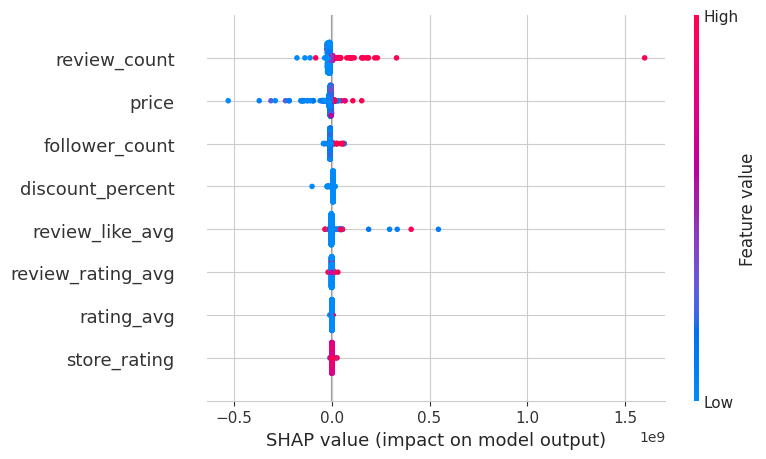

In [13]:
import shap

explainer = shap.Explainer(model_all)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

### SHAP là gì?

- **SHAP** (SHapley Additive exPlanations) là phương pháp giải thích mô hình, giúp phân rã dự báo thành đóng góp của từng feature.
- Giá trị **SHAP dương** làm tăng dự báo doanh thu, còn **SHAP âm** làm giảm dự báo; độ lớn tuyệt đối càng cao thì mức ảnh hưởng càng mạnh.
- Ở biểu đồ SHAP summary, trục ngang là mức tác động lên đầu ra mô hình và màu sắc thể hiện giá trị feature từ thấp đến cao, nhờ vậy có thể thấy được cả **độ quan trọng** lẫn **chiều tác động** của biến trước khi phân tích.

### Phân tích và kết luận

#### Các điểm nổi bật:

1. **Ở mức toàn bộ dữ liệu, mô hình ưu tiên nhóm tín hiệu về chất lượng và tương tác**. Feature importance (gain) cho thấy 4 biến đứng đầu là **rating_avg** (0.268), **review_count** (0.237), **price** (0.191) và **review_like_avg** (0.185), tức là mô hình đang dựa nhiều vào cả mức đánh giá lẫn độ sôi động của review.
2. **Khi tách theo root category, review_count là biến ổn định nhất**. Việc biến này đứng đầu ở cả 5 root (khoảng 0.62 đến 0.92) cho thấy quy mô tương tác thực tế có liên hệ rất mạnh với doanh thu dự đoán, ổn định hơn đa số biến còn lại. Nghĩa là để bất kỳ sản phẩm nào ở bất kỳ ngành nào có doanh thu cao, việc tạo ra nhiều review tích cực và tương tác là điều kiện gần như bắt buộc.
3. **Mỗi ngành có một đặc trưng doanh thu khác nhau**. Điện tử - Điện lạnh nổi bật thêm **follower_count**, trong khi Điện thoại - Máy tính bảng nhạy hơn với **review_rating_avg**, **discount_percent** và **price**, còn nhóm Laptop và Thiết bị số chịu tác động rõ hơn từ bài toán định giá.
4. **SHAP xác nhận trục tác động chính nằm ở review_count và price**. Các điểm SHAP cho thấy hai biến này tạo biên độ ảnh hưởng lớn nhất lên model output, còn **store_rating** thường nằm gần 0 nên vai trò dự báo tương đối thấp trong dữ liệu hiện tại.

#### Kết luận:

- **Không có một công thức, cách tính doanh thu dùng chung cho mọi ngành**. Vì đặc tính từng root khác nhau, chiến lược phân tích và tối ưu cần đi theo từng ngành thay vì áp một mẫu chung.
- Nếu ưu tiên tăng **revenue**, nên tập trung song song vào tăng chất lượng và số lượng review, đồng thời tối ưu **price/discount** theo bối cảnh danh mục. Cách làm này phù hợp với cả kết quả feature importance lẫn quan sát từ SHAP.

---
## KẾT LUẬN CHUNG

- Gộp từ cả hai câu hỏi, có thể thấy hiệu quả bán trên sàn e-commerce chịu tác động đồng thời bởi **chất lượng cảm nhận** và **động lực thị trường theo ngành**. Điều này nghĩa là quyết định tăng trưởng doanh số cần nhìn theo hệ biến kết hợp, không nên tách rời từng tín hiệu đơn lẻ.
- Ở **Câu 1**, rating phát huy rõ nhất ở vai trò ngưỡng và mốc **4.0 sao** là điểm chặn quan trọng. Khi đã vượt ngưỡng, doanh số không còn tăng tuyến tính đều ở mọi ngành, nên cách diễn giải phải gắn với cấu trúc từng danh mục.
- Ở **Câu 2**, mô hình cho thấy **review_count** là biến ổn định nhất theo mọi root category. Bên cạnh đó, **price**, **discount_percent** và **follower_count** đóng vai trò bổ sung theo từng ngành, nên thứ tự ưu tiên tối ưu không giống nhau.
- Riêng nhóm **Điện thoại - Máy tính bảng**, kết quả tiếp tục cho thấy thị trường bị chi phối mạnh bởi sản phẩm chủ lực và thương hiệu. Vì vậy, tương quan tuyến tính đơn giản có thể gây nhiễu nếu không đi kèm bối cảnh và vòng đời sản phẩm.
- Hàm ý thực thi là không nên dùng một playbook chung cho toàn bộ ngành hàng. Hướng an toàn hơn là giữ ngưỡng rating tốt, tăng chất lượng review, rồi tối ưu pricing/promotion theo đặc tính cầu của từng root category.